
# Causal Inference for the Tourism Industry

**A hands-on project based on Chapter 1 of *Causal Inference for Data Science*
(De Villa, Manning, 2025)**

Tourism boards, hotel chains, and travel platforms constantly ask causal
questions:

- Did our **destination marketing campaign** actually bring more visitors,
  or did visits just recover after the off-season anyway?
- Does buying a **City Tourist Pass** cause tourists to spend more, or do
  people who were already planning to spend a lot buy the pass anyway?
- Does a **loyalty / VIP upgrade** program increase guest satisfaction, or
  do the kind of guests who join loyalty programs just tend to be happier
  travelers to begin with?

This notebook works through two tourism case studies using the exact
5-step causal workflow and concepts from Chapter 1:

1. **Case Study A** — a before/after time-series problem (mirrors the
   book's own "Deploying a new website" example in section 1.3.1), applied
   to a tourism board's advertising campaign, confounded by **seasonality**.
2. **Case Study B** — a cross-sectional confounding problem (mirrors
   section 1.4.2's age/treatment/recovery DAG), applied to whether a
   **City Tourist Pass** causes higher visitor spending, confounded by
   **length of stay**.

Along the way: spurious correlations (tourism edition), the adjustment
idea, a simulated A/B test as the gold-standard benchmark, and conditional
expectations computed directly from data.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(2025)
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3



## Case Study A — Did the ad campaign work, or was it just tourist season?

### The scenario

A regional tourism board ran a **"Visit Us This Year"** advertising
campaign. A month after launch, daily visitor arrivals look like they shot
up. But the campaign happened to launch right before **peak season**. This
is precisely the trap the book warns about in section 1.3.1: an obvious
before/after jump can be driven by a confounder — here, **seasonality** —
rather than the intervention itself.

```
        Seasonality (time of year)
           /                    \
          v                      v
   Campaign launch time  -->  Visitor arrivals
```

Seasonality affects **when** a tourism board is likely to launch a campaign
(boards often launch right before high season, to maximize impact) *and*
it independently drives visitor arrivals. That makes campaign timing
confounded with the outcome, just like the book's website example.


In [2]:

days = np.arange(-60, 61)  # 60 days before and after campaign launch (day 0)

# Seasonality (confounder): a holiday lull just before launch, followed by a
# steeper natural post-holiday recovery -- exactly the "holiday timing" trap
# described in section 1.3.1 of the book. This calendar effect has nothing
# to do with the campaign, but it creates a sharp jump right around day 0.
seasonality = np.where(days < 0, 500 + 1.5 * days, 500 + 6.0 * days)

# True causal bump from the campaign: +80 visitors/day, starting at day 0
TRUE_CAMPAIGN_EFFECT = 80
campaign_on = (days >= 0).astype(int)

visitors = (
    seasonality
    + TRUE_CAMPAIGN_EFFECT * campaign_on
    + np.random.normal(0, 40, size=len(days))
)

ts = pd.DataFrame({'day': days, 'campaign_on': campaign_on,
                    'seasonality': seasonality, 'visitors': visitors})
ts.head()


,day,campaign_on,seasonality,visitors
0,-60,0,410.0,406.304393
1,-59,0,411.5,440.871423
2,-58,0,413.0,355.444719
3,-57,0,414.5,387.963119
4,-56,0,416.0,411.970876


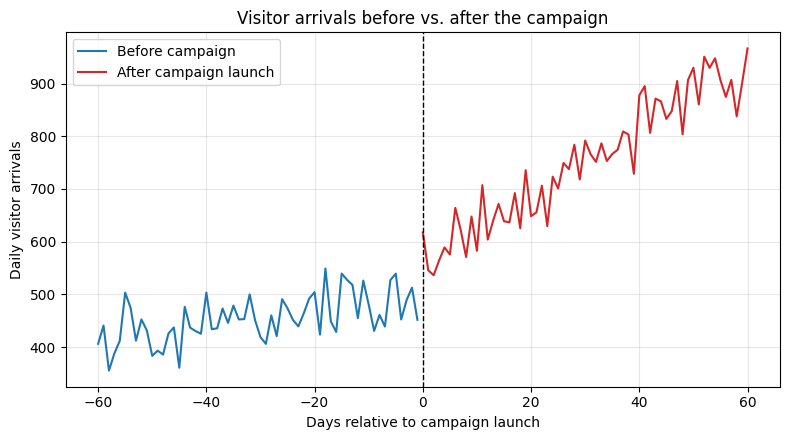

In [3]:

fig, ax = plt.subplots()
ax.plot(ts.day[ts.campaign_on == 0], ts.visitors[ts.campaign_on == 0],
        color='#1f77b4', label='Before campaign')
ax.plot(ts.day[ts.campaign_on == 1], ts.visitors[ts.campaign_on == 1],
        color='#d62728', label='After campaign launch')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Days relative to campaign launch')
ax.set_ylabel('Daily visitor arrivals')
ax.set_title('Visitor arrivals before vs. after the campaign')
ax.legend()
plt.tight_layout()
plt.show()



Just like figure 1.2 in the book, this looks like a clear win for the
campaign. But part of that rise is simply the calendar moving toward high
season — the campaign launched right as seasonality was already climbing.


In [4]:

naive_effect = ts.loc[ts.campaign_on == 1, 'visitors'].mean() - \
               ts.loc[ts.campaign_on == 0, 'visitors'].mean()

print(f"Naive before/after difference = {naive_effect:.1f} visitors/day")
print(f"True campaign effect           = {TRUE_CAMPAIGN_EFFECT} visitors/day")


Naive before/after difference = 297.3 visitors/day
True campaign effect           = 80 visitors/day



The naive estimate **overstates** the true effect, because it also scoops
up the seasonal upswing that would have happened with or without the
campaign.

### Adjusting for seasonality

We can't re-run this exact year without the campaign, but we *do* know
the seasonal pattern (e.g., from last year's data, or from a smooth trend
model). The book's suggestion in section 1.3.1 is to compare against the
**same period last year**, or more generally, to control for the known
confounder directly. Here, since we (as the simulation's author) know the
`seasonality` term, let's adjust for it directly — this is the intuition
behind the adjustment formula in chapter 2, and behind time-series
techniques like **differences-in-differences** previewed in section 1.1.5.


In [5]:

# Adjustment: subtract out the (known) seasonal component, then compare
ts['visitors_deseasonalized'] = ts['visitors'] - ts['seasonality']

adjusted_effect = (ts.loc[ts.campaign_on == 1, 'visitors_deseasonalized'].mean()
                    - ts.loc[ts.campaign_on == 0, 'visitors_deseasonalized'].mean())

print(f"Naive before/after difference       = {naive_effect:.1f}")
print(f"Seasonality-adjusted difference     = {adjusted_effect:.1f}")
print(f"True campaign effect                = {TRUE_CAMPAIGN_EFFECT}")


Naive before/after difference       = 297.3
Seasonality-adjusted difference     = 71.6
True campaign effect                = 80



Once we strip out the seasonal trend, the estimate lands very close to the
true campaign effect of **+80 visitors/day**. In practice, tourism boards
rarely know the exact seasonal function — they'd estimate it from
historical data (e.g., last year's daily arrivals, holidays, weather) —
but the logic is the same: **hold the confounder fixed, then measure the
remaining difference.**



## Case Study B — Does the City Tourist Pass increase spending?

### The scenario

A city sells an optional **"City Pass"** bundling museum entry, transit,
and discounts. The tourism authority wants to know: **does buying the
pass cause tourists to spend more overall** (including outside the pass
itself — restaurants, shopping, extra activities)?

The catch: tourists staying **longer** in the city are both **more likely
to buy the pass** (better value for a longer trip) and **naturally spend
more** overall, simply because they have more days to spend money. Length
of stay is a **confounder** — the same DAG as section 1.4.2's
age/treatment/recovery example, with `age` swapped for `length of stay`:

```
      Length of stay (confounder)
          /                 \
         v                   v
   Buys City Pass  -------> Total spending
```


In [6]:

n = 6000

# Confounder: length of stay, in days (1-14)
length_of_stay = np.random.uniform(1, 14, size=n)

# Pass purchase probability rises with length of stay (selection into "treatment")
prob_pass = 1 / (1 + np.exp(-0.35 * (length_of_stay - 7)))
buys_pass = np.random.binomial(1, prob_pass)

# True causal effect of the pass on total spending: +120 (dollars)
TRUE_PASS_EFFECT = 120

total_spending = (
    150                          # baseline spending
    + 60 * length_of_stay        # more days -> more spending, regardless of pass
    + TRUE_PASS_EFFECT * buys_pass  # <-- the causal effect we want to recover
    + np.random.normal(0, 80, size=n)
)

tour = pd.DataFrame({
    'length_of_stay': length_of_stay,
    'buys_pass': buys_pass,
    'total_spending': total_spending
})
tour.head()


,length_of_stay,buys_pass,total_spending
0,10.217314,0,694.804735
1,13.607234,0,983.189403
2,9.710187,1,800.341941
3,7.914015,1,726.606187
4,10.581517,1,806.846954


In [7]:

naive_pass_effect = (tour.loc[tour.buys_pass == 1, 'total_spending'].mean()
                      - tour.loc[tour.buys_pass == 0, 'total_spending'].mean())

print(f"E[spending | buys pass]    = {tour.loc[tour.buys_pass==1,'total_spending'].mean():.1f}")
print(f"E[spending | no pass]      = {tour.loc[tour.buys_pass==0,'total_spending'].mean():.1f}")
print(f"Naive difference           = {naive_pass_effect:.1f}")
print(f"True causal effect of pass = {TRUE_PASS_EFFECT}")


E[spending | buys pass]    = 833.4
E[spending | no pass]      = 474.2
Naive difference           = 359.2
True causal effect of pass = 120



The naive comparison **overstates** the pass's true effect on spending,
because pass-buyers are systematically staying longer — and would have
spent more even without the pass.


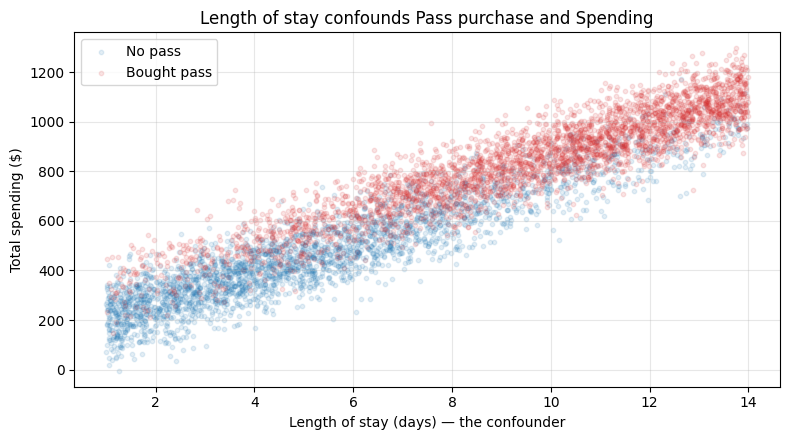

In [8]:

fig, ax = plt.subplots()
for t, color, label in [(0, '#1f77b4', 'No pass'), (1, '#d62728', 'Bought pass')]:
    subset = tour[tour.buys_pass == t]
    ax.scatter(subset.length_of_stay, subset.total_spending, alpha=0.12, s=10,
               color=color, label=label)
ax.set_xlabel('Length of stay (days) — the confounder')
ax.set_ylabel('Total spending ($)')
ax.set_title('Length of stay confounds Pass purchase and Spending')
ax.legend()
plt.tight_layout()
plt.show()



### Adjusting by stratifying on length of stay

Just as in the wage/training project, we compare pass-buyers and
non-buyers **within narrow bands of length of stay** — apples to apples —
then average those within-band differences back up.


In [9]:

tour['stay_bin'] = pd.cut(tour.length_of_stay, bins=10)

strata = (
    tour.groupby('stay_bin', observed=True)
        .apply(lambda d: pd.Series({
            'n': len(d),
            'mean_pass': d.loc[d.buys_pass == 1, 'total_spending'].mean(),
            'mean_no_pass': d.loc[d.buys_pass == 0, 'total_spending'].mean(),
        }), include_groups=False)
)
strata['effect'] = strata['mean_pass'] - strata['mean_no_pass']
strata


,n,mean_pass,mean_no_pass,effect
stay_bin,,,,
"(0.991, 2.303]",566.0,371.203842,244.170384,127.033459
"(2.303, 3.601]",560.0,437.125040,326.842279,110.282761
"(3.601, 4.9]",610.0,529.208929,404.509992,124.698937
"(4.9, 6.198]",588.0,596.401163,470.089378,126.311784
"(6.198, 7.497]",644.0,694.412904,567.188561,127.224343
"(7.497, 8.795]",628.0,755.842662,629.777364,126.065298
"(8.795, 10.094]",578.0,840.062144,716.719471,123.342673
"(10.094, 11.393]",652.0,914.386697,797.526897,116.859799
"(11.393, 12.691]",582.0,989.472079,881.046153,108.425927


In [10]:

adjusted_pass_effect = np.average(strata['effect'].dropna(),
                                   weights=strata.loc[strata['effect'].notna(), 'n'])

print(f"Naive (unadjusted) difference = {naive_pass_effect:.1f}")
print(f"Adjusted (stratified) effect  = {adjusted_pass_effect:.1f}")
print(f"True causal effect            = {TRUE_PASS_EFFECT}")


Naive (unadjusted) difference = 359.2
Adjusted (stratified) effect  = 121.6
True causal effect            = 120



Adjusting for length of stay brings the estimate **much closer** to the
true effect of **+$120**.



### The gold standard: what if the pass had been A/B tested?

Suppose instead the city had run a genuine experiment: at the airport
welcome desk, every arriving tourist is **randomly** offered a free City
Pass (say, via a coin flip), independent of how long they're staying.
Section 1.3.2 of the book explains why this removes confounding by
design — random assignment balances length of stay across both groups
automatically.


In [11]:

np.random.seed(11)
length_of_stay_ab = np.random.uniform(1, 14, size=n)
buys_pass_ab = np.random.binomial(1, 0.5, size=n)  # <-- randomized, not selected

total_spending_ab = (
    150
    + 60 * length_of_stay_ab
    + TRUE_PASS_EFFECT * buys_pass_ab
    + np.random.normal(0, 80, size=n)
)

ab = pd.DataFrame({'length_of_stay': length_of_stay_ab,
                    'buys_pass': buys_pass_ab,
                    'total_spending': total_spending_ab})

ab_ate = (ab.loc[ab.buys_pass == 1, 'total_spending'].mean()
          - ab.loc[ab.buys_pass == 0, 'total_spending'].mean())

print(f"A/B test difference in means (no adjustment needed) = {ab_ate:.1f}")
print(f"True causal effect                                   = {TRUE_PASS_EFFECT}")


A/B test difference in means (no adjustment needed) = 128.3
True causal effect                                   = 120


In [12]:

comparison = pd.DataFrame({
    'Method': ['True effect', 'Naive (observational, unadjusted)',
               'Adjusted (observational, stratified)', 'A/B test (difference in means)'],
    'Estimate ($)': [TRUE_PASS_EFFECT, naive_pass_effect, adjusted_pass_effect, ab_ate]
})
comparison


,Method,Estimate ($)
0,True effect,120.000000
1,"Naive (observational, unadjusted)",359.227784
2,"Adjusted (observational, stratified)",121.632357
3,A/B test (difference in means),128.330563


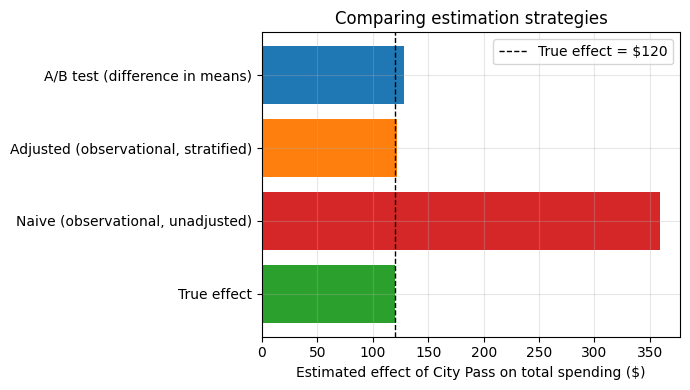

In [13]:

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4']
ax.barh(comparison['Method'], comparison['Estimate ($)'], color=colors)
ax.axvline(TRUE_PASS_EFFECT, color='black', linestyle='--', linewidth=1,
           label=f'True effect = ${TRUE_PASS_EFFECT}')
ax.set_xlabel('Estimated effect of City Pass on total spending ($)')
ax.set_title('Comparing estimation strategies')
ax.legend()
plt.tight_layout()
plt.show()



## Spurious correlation, tourism edition

Section 1.4 of the book shows arcade revenue vs. computer-science PhDs —
highly correlated, not causally linked, both driven by population growth.
Here's a tourism-flavored version: **beach-town ice cream sales** and
**sunscreen sales**, both driven by the hidden factor of **summer tourist
traffic**.

```
              Summer tourist traffic
                /                \
               v                  v
      Ice cream sales        Sunscreen sales
```

No arrow runs between ice cream and sunscreen sales directly — but if you
only saw the two sales series, you might think one drives the other (or
even try to "predict" one from the other).


In [14]:

np.random.seed(3)
weeks = np.arange(1, 27)  # 26 weeks of summer season data across several beach towns
tourist_traffic = 1000 + 150 * np.sin(weeks / 26 * np.pi) + np.random.normal(0, 20, len(weeks))

ice_cream_sales = 200 + 0.9 * (tourist_traffic - 1000) + np.random.normal(0, 15, len(weeks))
sunscreen_sales = 500 + 2.1 * (tourist_traffic - 1000) + np.random.normal(0, 30, len(weeks))

spurious = pd.DataFrame({'week': weeks, 'ice_cream_sales': ice_cream_sales,
                          'sunscreen_sales': sunscreen_sales})
corr = np.corrcoef(spurious.ice_cream_sales, spurious.sunscreen_sales)[0, 1]
print(f"Correlation between ice cream sales and sunscreen sales: {corr:.3f}")


Correlation between ice cream sales and sunscreen sales: 0.852


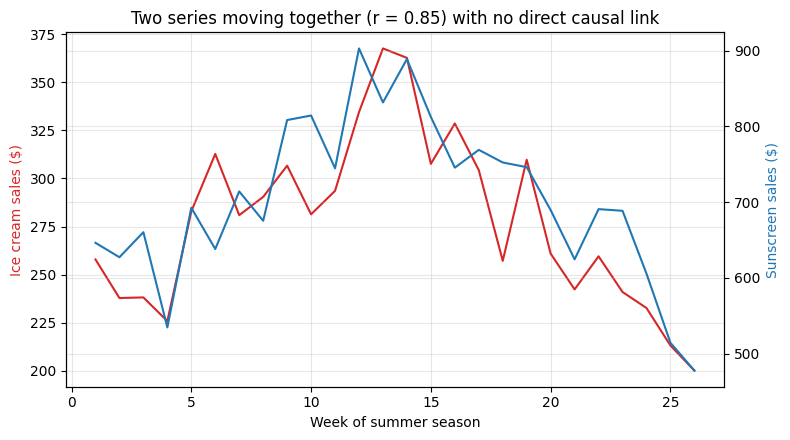

In [15]:

fig, ax1 = plt.subplots()
ax1.plot(spurious.week, spurious.ice_cream_sales, color='#d62728', label='Ice cream sales')
ax1.set_xlabel('Week of summer season')
ax1.set_ylabel('Ice cream sales ($)', color='#d62728')
ax2 = ax1.twinx()
ax2.plot(spurious.week, spurious.sunscreen_sales, color='#1f77b4', label='Sunscreen sales')
ax2.set_ylabel('Sunscreen sales ($)', color='#1f77b4')
plt.title(f'Two series moving together (r = {corr:.2f}) with no direct causal link')
plt.tight_layout()
plt.show()



Both series track the shared driver — tourist traffic across the summer
season — not each other. A tourism analyst who ignored this could make a
costly mistake, e.g., trying to boost sunscreen sales by discounting ice
cream, when the real lever is attracting more visitors in the first
place.



## Conditional expectations recap

As in section 1.5.2, everything above boils down to conditional
expectations, `E[Y | X]`. Let's build the table by hand for the City
Pass case, the same way the book builds tables 1.1–1.4.


In [16]:

cond_exp = (
    tour.assign(stay_group=pd.cut(tour.length_of_stay, bins=[0, 3.5, 7, 10.5, 14],
                                   labels=['1-3.5 days', '3.5-7 days',
                                           '7-10.5 days', '10.5-14 days']))
        .groupby(['stay_group', 'buys_pass'], observed=True)['total_spending']
        .mean()
        .unstack('buys_pass')
        .rename(columns={0: 'E[spending | no pass]', 1: 'E[spending | pass]'})
)
cond_exp['within-group effect ($)'] = (cond_exp['E[spending | pass]']
                                        - cond_exp['E[spending | no pass]'])
cond_exp


buys_pass,E[spending | no pass],E[spending | pass],within-group effect ($)
stay_group,,,
1-3.5 days,281.613345,404.334784,122.721439
3.5-7 days,455.215329,602.534955,147.319626
7-10.5 days,661.980944,803.137036,141.156092
10.5-14 days,871.992378,1004.223767,132.231389



Within every length-of-stay band, pass buyers spend roughly **$120 more**
— matching the true effect built into the data. Confirming an estimate
"holds up within strata" like this is a useful sanity check any time you
adjust for a confounder.



## Exercises — extend this project

1. **Add a second confounder to Case Study B.** Add `travel_party_size`
   (number of people traveling together), which plausibly affects both
   the decision to buy a City Pass (bulk discounts) and total spending.
   Does 1-D stratification on `length_of_stay` alone still fully remove
   the bias?
2. **Weather as a confounder in Case Study A.** Add a `rainy_day` variable
   that reduces visitor arrivals and is more common in certain months.
   Does adjusting only for `seasonality` (and not weather) leave residual
   bias in the campaign-effect estimate?
3. **External validity.** Suppose the City Pass A/B test only ran at the
   airport, so it only reached tourists arriving by plane (not by car or
   train). Restrict the `ab` DataFrame to `length_of_stay > 5` (mimicking
   a subgroup more likely to fly in for longer trips) and recompute the
   ATE. Discuss whether this estimate would generalize to all visitors.
4. **Try a regression-based adjustment.** Instead of stratifying into
   bins, fit `total_spending ~ buys_pass + length_of_stay` with
   `statsmodels.OLS` and compare the coefficient on `buys_pass` to the
   stratified estimate above. This previews the regression-based version
   of the adjustment formula covered in chapter 2.
5. **Design your own tourism A/B test.** Pick a real intervention (e.g., a
   hotel's free-breakfast offer, a museum's free-guide-app promotion) and
   sketch: what's the treatment, what's the outcome, and what's the most
   likely confounder if you only had observational data?

## Summary

- Before/after comparisons in tourism data (e.g., a marketing campaign)
  can be confounded by **seasonality** — exactly like the book's website
  example, just applied to visitor arrivals.
- Cross-sectional "did the perk cause more spending" questions (City Pass,
  loyalty programs, upgrades) are often confounded by **trip
  characteristics** like length of stay.
- Stratifying/adjusting for the confounder recovers estimates close to
  the true causal effect; a properly randomized A/B test recovers it
  without any adjustment at all.
- Two tourism metrics can move together strongly (ice cream vs. sunscreen
  sales) purely because of a shared driver (tourist season) — not because
  one causes the other.
